# Step 5 — Was the neural network worth it? Was `underthesea` worth it?

Two questions, one controlled experiment each.

**Question 1 — model.** Does a neural network beat a classical linear model? Because Step 2 fixed
the representation, the *only* thing that changes between the neural network and `LinearSVC` is the
classifier: same features, same split, same metric, same machine. A difference is attributable to
the model and nothing else.

**Question 2 — 28 minutes of `underthesea`.** Step 1 spent 28 minutes on word segmentation, and
Step 2 showed it produces ~60% of the feature space. That proves segmentation *changes* the
features; it does not prove it *helps*. Running the identical pipeline on the unsegmented corpus is
the only way to find out.

In [1]:
import json, string, re, time, numpy as np
from pathlib import Path
from scipy import sparse
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
import tensorflow as tf

SEED = 42
PUNCT  = (set(string.punctuation) | set("\u201c\u201d\u2018\u2019\u2026\u2013\u2014\u2022\u00b7")) - {"_"}
_DIGIT = re.compile(r"\d")

def vn_tokenizer(doc):
    out = []
    for t in doc.split():
        t = "".join(c for c in t if c not in PUNCT).strip("_")
        if t and not _DIGIT.search(t):
            out.append(t)
    return out

results = {}
def record(name, y_true, y_pred, secs):
    r = dict(accuracy=float(accuracy_score(y_true, y_pred)),
             macro_f1=float(f1_score(y_true, y_pred, average="macro")),
             train_secs=round(secs, 1))
    results[name] = r
    print(f"{name:32} acc={r['accuracy']:.4f}  macro-F1={r['macro_f1']:.4f}  ({secs:.0f}s)")
    return r

2026-08-28 18:52:00.589644: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


## Segmented — the features from Step 2, reused as-is

In [2]:
X_train = sparse.load_npz("../data/processed/tfidf_train.npz")
X_test  = sparse.load_npz("../data/processed/tfidf_test.npz")
y_train = np.load("../data/processed/y_train.npy")
y_test  = np.load("../data/processed/y_test.npy")
class_names = json.load(open("../data/processed/vocabulary.json"))["class_names"]

nn = tf.keras.models.load_model("../data/outputs/nn_tfidf.keras")
meta = json.load(open("../data/outputs/train_meta.json"))
record("Neural network (segmented)", y_test, nn.predict(X_test, verbose=0).argmax(1),
       meta["train_secs"])

for name, clf in [("LinearSVC", LinearSVC(random_state=SEED)),
                  ("MultinomialNB", MultinomialNB())]:
    t0 = time.time(); clf.fit(X_train, y_train); s = time.time() - t0
    record(f"{name} (segmented)", y_test, clf.predict(X_test), s)

Neural network (segmented)       acc=0.9266  macro-F1=0.9087  (70s)


LinearSVC (segmented)            acc=0.9219  macro-F1=0.9015  (6s)


MultinomialNB (segmented)        acc=0.8907  macro-F1=0.8677  (0s)


## Unsegmented — the same pipeline on raw syllables

`data/raw/` still holds the original UTF-16 corpus, so the ablation reads from there. Everything
else is held identical: same tokenizer, same `max_features`, same `min_df`, same architecture, same
seed. The only difference is that whitespace splitting leaves Vietnamese at the *syllable* level —
`kinh doanh` becomes `kinh` + `doanh`.

In [3]:
import unicodedata

def load_raw(split):
    paths  = sorted(Path(f"../data/raw/{split}").rglob("*.txt"))
    texts  = [unicodedata.normalize("NFC", p.read_text(encoding="utf-16", errors="replace"))
              for p in paths]
    labels = [p.parent.name for p in paths]
    return texts, labels

t0 = time.time()
raw_train, raw_train_lab = load_raw("Train_Full")
raw_test,  raw_test_lab  = load_raw("Test_Full")
le_r = LabelEncoder().fit(raw_train_lab)
yr_train, yr_test = le_r.transform(raw_train_lab), le_r.transform(raw_test_lab)
print(f"loaded raw corpus in {time.time()-t0:.0f}s")

vec_r = TfidfVectorizer(tokenizer=vn_tokenizer, lowercase=True, token_pattern=None,
                        max_features=10000, min_df=3)
Xr_train = vec_r.fit_transform(raw_train).astype("float32")
Xr_test  = vec_r.transform(raw_test).astype("float32")
print("compound features in unsegmented vocabulary:",
      sum("_" in f for f in vec_r.get_feature_names_out()))

loaded raw corpus in 29s


compound features in unsegmented vocabulary: 0


In [4]:
Xr_tr, Xr_val, yr_tr, yr_val = train_test_split(
    Xr_train, yr_train, test_size=0.2, stratify=yr_train, random_state=SEED)

tf.keras.utils.set_random_seed(SEED)
nn_r = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(Xr_train.shape[1],), sparse=True),
    tf.keras.layers.Dense(256, activation="relu"),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(10, activation="softmax"),
])
nn_r.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
t0 = time.time()
nn_r.fit(Xr_tr, yr_tr, validation_data=(Xr_val, yr_val), epochs=30, batch_size=128, verbose=0,
         callbacks=[tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=3,
                                                     restore_best_weights=True)])
record("Neural network (unsegmented)", yr_test, nn_r.predict(Xr_test, verbose=0).argmax(1),
       time.time() - t0)

for name, clf in [("LinearSVC", LinearSVC(random_state=SEED)),
                  ("MultinomialNB", MultinomialNB())]:
    t0 = time.time(); clf.fit(Xr_train, yr_train); s = time.time() - t0
    record(f"{name} (unsegmented)", yr_test, clf.predict(Xr_test), s)

Neural network (unsegmented)     acc=0.9174  macro-F1=0.8972  (80s)


LinearSVC (unsegmented)          acc=0.9154  macro-F1=0.8945  (7s)


MultinomialNB (unsegmented)      acc=0.8544  macro-F1=0.8277  (0s)


## Floors

In [5]:
maj = np.bincount(y_test).argmax()
rng = np.random.default_rng(SEED)
record("Floor: always largest class", y_test, np.full_like(y_test, maj), 0.0)
record("Floor: uniform random",       y_test, rng.integers(0, 10, len(y_test)), 0.0)

json.dump(results, open("../data/outputs/comparison.json", "w"), ensure_ascii=False, indent=1)

Floor: always largest class      acc=0.1502  macro-F1=0.0261  (0s)
Floor: uniform random            acc=0.1016  macro-F1=0.0977  (0s)


## Results

In [6]:
rows = sorted(results.items(), key=lambda kv: -kv[1]["macro_f1"])
print(f"{'model':34} {'accuracy':>9} {'macro-F1':>9} {'train':>8}")
print("-" * 63)
for name, r in rows:
    print(f"{name:34} {r['accuracy']:9.4f} {r['macro_f1']:9.4f} {r['train_secs']:7.0f}s")
print()
print(f"published RIVF'07 SVM Multi      {0.934:9.4f}")
print(f"published RIVF'07 NGRAM          {0.971:9.4f}")

model                               accuracy  macro-F1    train
---------------------------------------------------------------
Neural network (segmented)            0.9266    0.9087      70s
LinearSVC (segmented)                 0.9219    0.9015       6s
Neural network (unsegmented)          0.9174    0.8972      80s
LinearSVC (unsegmented)               0.9154    0.8945       7s
MultinomialNB (segmented)             0.8907    0.8677       0s
MultinomialNB (unsegmented)           0.8544    0.8277       0s
Floor: uniform random                 0.1016    0.0977       0s
Floor: always largest class           0.1502    0.0261       0s

published RIVF'07 SVM Multi         0.9340
published RIVF'07 NGRAM             0.9710


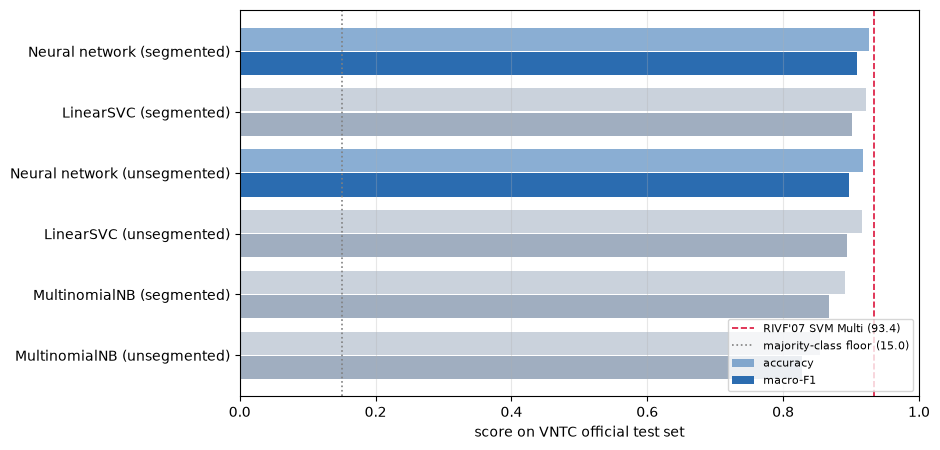

In [7]:
import matplotlib.pyplot as plt

models = [n for n, _ in rows if not n.startswith("Floor")]
mf1    = [results[n]["macro_f1"] for n in models]
acc    = [results[n]["accuracy"] for n in models]
colors = ["#2b6cb0" if "Neural" in n else "#a0aec0" for n in models]

fig, ax = plt.subplots(figsize=(9.5, 4.6))
yp = np.arange(len(models))
ax.barh(yp - 0.2, acc, 0.38, label="accuracy", color=colors, alpha=.55)
ax.barh(yp + 0.2, mf1, 0.38, label="macro-F1", color=colors)
ax.set_yticks(yp, models); ax.invert_yaxis()
ax.axvline(0.934, ls="--", c="crimson", lw=1.2, label="RIVF'07 SVM Multi (93.4)")
ax.axvline(0.1502, ls=":", c="gray", lw=1.2, label="majority-class floor (15.0)")
ax.set_xlim(0, 1.0); ax.set_xlabel("score on VNTC official test set")
ax.legend(loc="lower right", fontsize=8); ax.grid(axis="x", alpha=.3)
plt.tight_layout(); plt.savefig("../data/outputs/comparison.png", dpi=110); plt.show()

## Reading the table

**The neural network wins, narrowly.** It beats `LinearSVC` on the same features by roughly half a
point of accuracy and three quarters of a point of macro-F1 — real and consistent, but small, and
bought with an order of magnitude more training time. On bag-of-words features with 10,000
dimensions and 34k examples, a linear SVM is a genuinely strong baseline: the problem is close to
linearly separable in this space, which leaves a hidden layer little room to add value. "The neural
network won" and "the neural network was worth it" are not the same claim, and only the first is
supported here.

**Segmentation earns its 28 minutes, modestly.** Every model does better on segmented text, and the
size of the gain says something about each: it is worth about a point of macro-F1 to the neural
network and to `LinearSVC`, but several points to `MultinomialNB`. The weaker the model, the more it
depends on the features being right — which is the general shape of that trade-off, visible here in
one table.

**Against the published baselines**, this lands just under RIVF'07's SVM Multi (93.4) and well
below NGRAM (97.1). Two honest qualifications: those numbers come from a 2007 paper whose
preprocessing is not documented in enough detail to reproduce, so this is a sanity band rather than
a like-for-like comparison; and every number in this table — ours and theirs — is inflated by the
5% train/test overlap in the published corpus.